# Model Comparison using 5-Fold Cross Validation

## Objectives

- Compare Linear Regression, Random Forest and XGBoost
- Evaluate using identical folds
- Compute mean R² and standard deviation
- Visualize model performance
- Select the best model

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

plt.style.use("ggplot")

In [9]:
X = pd.read_csv("../data/processed/X_train.csv")
y = pd.read_csv("../data/processed/y_train.csv")

In [10]:
X.columns = (
    X.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

In [11]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [12]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
linear_scores = cross_val_score(
    linear_model,
    X,
    y.values.ravel(),
    cv=kfold,
    scoring="r2"
)

rf_scores = cross_val_score(
    rf_model,
    X,
    y.values.ravel(),
    cv=kfold,
    scoring="r2"
)

xgb_scores = cross_val_score(
    xgb_model,
    X,
    y.values.ravel(),
    cv=kfold,
    scoring="r2"
)

In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Mean R²": [
        linear_scores.mean(),
        rf_scores.mean(),
        xgb_scores.mean()
    ],

    "Std Dev": [
        linear_scores.std(),
        rf_scores.std(),
        xgb_scores.std()
    ]
})

results = results.sort_values(
    by="Mean R²",
    ascending=False
)

display(results)

,Model,Mean R²,Std Dev
1,Random Forest,0.993857,0.001317
2,XGBoost,0.993132,0.001158
0,Linear Regression,0.950306,0.006179


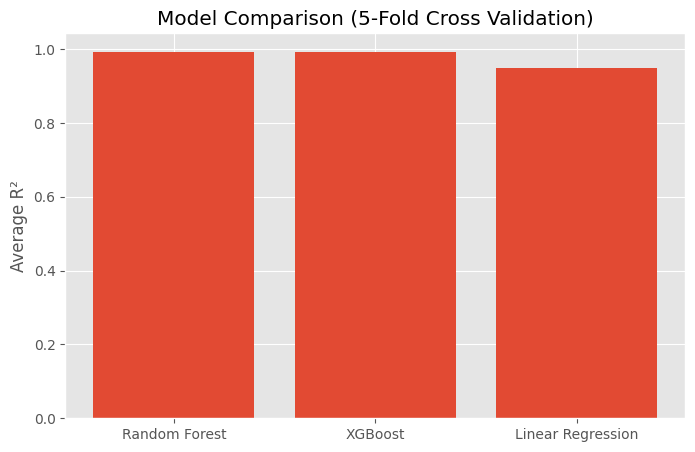

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Mean R²"]
)

plt.ylabel("Average R²")
plt.title("Model Comparison (5-Fold Cross Validation)")

plt.show()

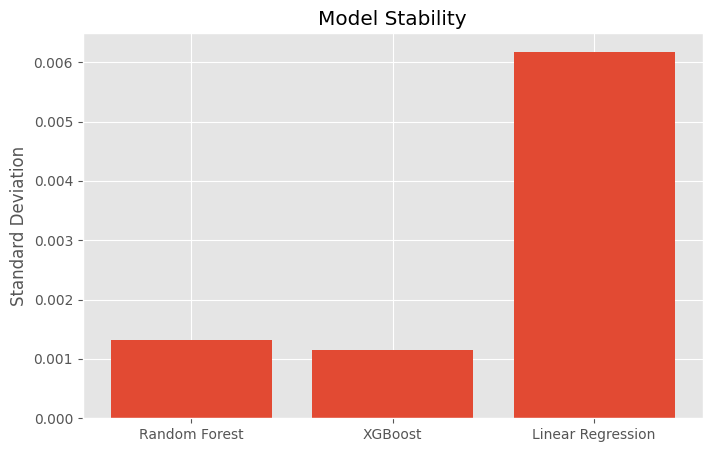

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Std Dev"]
)

plt.ylabel("Standard Deviation")
plt.title("Model Stability")

plt.show()

In [17]:
best_model = results.iloc[0]

print("="*50)
print("Best Performing Model")
print("="*50)

print(f"Model        : {best_model['Model']}")
print(f"Average R²   : {best_model['Mean R²']:.5f}")
print(f"Std Dev      : {best_model['Std Dev']:.5f}")

Best Performing Model
Model        : Random Forest
Average R²   : 0.99386
Std Dev      : 0.00132


In [19]:
comparison = pd.DataFrame({
    "Fold": [
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5"
    ],

    "Linear Regression": linear_scores,
    "Random Forest": rf_scores,
    "XGBoost": xgb_scores
})

# Find the best model for each fold
comparison["Best Model"] = comparison[
    ["Linear Regression", "Random Forest", "XGBoost"]
].idxmax(axis=1)

# Best score for each fold
comparison["Best R²"] = comparison[
    ["Linear Regression", "Random Forest", "XGBoost"]
].max(axis=1)

display(comparison)

,Fold,Linear Regression,Random Forest,XGBoost,Best Model,Best R²
0,Fold 1,0.939334,0.994808,0.993634,Random Forest,0.994808
1,Fold 2,0.950954,0.995749,0.994428,Random Forest,0.995749
2,Fold 3,0.954232,0.993128,0.991327,Random Forest,0.993128
3,Fold 4,0.949370,0.991954,0.992264,XGBoost,0.992264
4,Fold 5,0.957639,0.993647,0.994007,XGBoost,0.994007


In [20]:
wins = comparison["Best Model"].value_counts()

print("=" * 50)
print("Number of Fold Wins")
print("=" * 50)

print(wins)

Number of Fold Wins
Best Model
Random Forest    3
XGBoost          2
Name: count, dtype: int64
